# Load Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pygenelab as pgl

In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import decoupler as dc

# Load Dataset

In [4]:
# load mice dataset
MICE_DATASET_PATH = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad"
adata_mice = sc.read_h5ad(MICE_DATASET_PATH)
adata_mice_female_iix_iib = pgl.subset_adata_by_obs(adata_mice,
                                                    filters={"sex": "F",
                                                             "C_scANVI": ["Fast IIX", "Fast IIB"]})

In [5]:
# load human dataset
FEMALE_HUMAN_DATASET_PATH = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/tmp/myofibers_female.h5ad"
adata_human_f = sc.read_h5ad(FEMALE_HUMAN_DATASET_PATH)
adata_human_female_typeii = pgl.subset_adata_by_obs(adata_human_f,
                                                    filters={"Annotation": ["Type II"]})

In [6]:
# find common genes in both dataset

# get gene names
mouse_genes = adata_mice_female_iix_iib.var_names.astype(str)
human_genes = adata_human_female_typeii.var_names.astype(str)

# convert mouse genes to uppercase
mouse_genes_upper = pd.Index(mouse_genes).str.upper()

# find overlap using uppercase mouse genes
common_genes = sorted(set(mouse_genes_upper).intersection(set(human_genes)))

print(f"Mouse Genes: {len(mouse_genes)}")
print(f"Human Genes: {len(human_genes)}")
print(f"Common Genes: {len(common_genes)}")

Mouse Genes: 3000
Human Genes: 48355
Common Genes: 2240


In [7]:
# subset human data with common genes
adata_human_female_typeii_common_genes = adata_human_female_typeii[:, common_genes].copy()

print(adata_human_female_typeii_common_genes.shape)

(17625, 2240)


# Load Geneset

In [8]:
# specify pathway
PATHWAY = "REACTOME_PYRUVATE_METABOLISM"

# load geneset
MICE_ALL_PATHWAYS_PATH = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"
geneset = pgl.convert_gmt_to_decoupler_format(MICE_ALL_PATHWAYS_PATH, 
                                              include_pathways=[PATHWAY], 
                                              gene_origin="human")

display(len(geneset))
display(geneset.head())

45

,source,target
0,REACTOME_PYRUVATE_METABOLISM,ARMC8
1,REACTOME_PYRUVATE_METABOLISM,DLAT
2,REACTOME_PYRUVATE_METABOLISM,DLD
3,REACTOME_PYRUVATE_METABOLISM,FAHD1
4,REACTOME_PYRUVATE_METABOLISM,GID4


In [13]:
# check how many genes are present in adata
genes_in_adata = pgl.check_genes_in_adata(geneset, adata_human_female_typeii_common_genes)
display(genes_in_adata["matched_genes"])

['LDHB', 'ME3', 'PDK4']

# Calculate Scores

In [14]:
%%time

dc.mt.aucell(
    adata_human_female_typeii_common_genes,
    geneset,
    raw=False,
    verbose=True,
    tmin=3 # only 3 common genes are present
)

2026-05-19 11:02:27 | [INFO] aucell - Running aucell
2026-05-19 11:02:27 | [INFO] Extracted omics mat with 17625 rows (observations) and 2240 columns (features)
2026-05-19 11:02:27 | [WARNING] 11 features of mat are empty, they will be removed
2026-05-19 11:02:27 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-05-19 11:02:27 | [INFO] Network has 3 unique features and 1 unique sources
2026-05-19 11:02:27 | [INFO] aucell - calculating 1 AUCs for 2229 targets across 17625 observations, categorizing features at rank=112
100%|██████████| 17625/17625 [00:10<00:00, 1663.89it/s]
2026-05-19 11:02:38 | [INFO] aucell - done


CPU times: user 3min 54s, sys: 173 ms, total: 3min 54s
Wall time: 10.9 s


In [15]:
# add score column to obs
adata_human_female_typeii_common_genes.obs[PATHWAY] = adata_human_female_typeii_common_genes.obsm["score_aucell"].copy()
display(adata_human_female_typeii_common_genes.obs[PATHWAY].head())

CELL3027_N1_1_1_2_1_1    0.139394
CELL1008_N1_1_1_2_1_1    0.293939
CELL908_N1_1_1_2_1_1     0.321212
CELL1209_N1_1_1_2_1_1    0.321212
CELL267_N2_1_1_2_1_1     0.309091
Name: REACTOME_PYRUVATE_METABOLISM, dtype: float64

In [16]:
# prepare summary
group_col = "age"
value_col = PATHWAY
group_score_df = pgl.prepare_group_score_df(adata_human_female_typeii_common_genes, group_col=group_col, value_col=value_col)
summary = pgl.summarize_score_by_group(group_score_df, group_col=group_col, score_col=value_col)
display(summary.head())

,age,count,mean,median,std,min,max
0,17,97,0.003124,0.000000,0.021643,0.0,0.151515
1,34,3456,0.021195,0.000000,0.060266,0.0,0.484848
2,79,372,0.197198,0.248485,0.139775,0.0,0.554545
3,80,12255,0.050589,0.000000,0.096616,0.0,0.575758
4,82,235,0.286319,0.318182,0.098296,0.0,0.530303


# Violin Box Plot

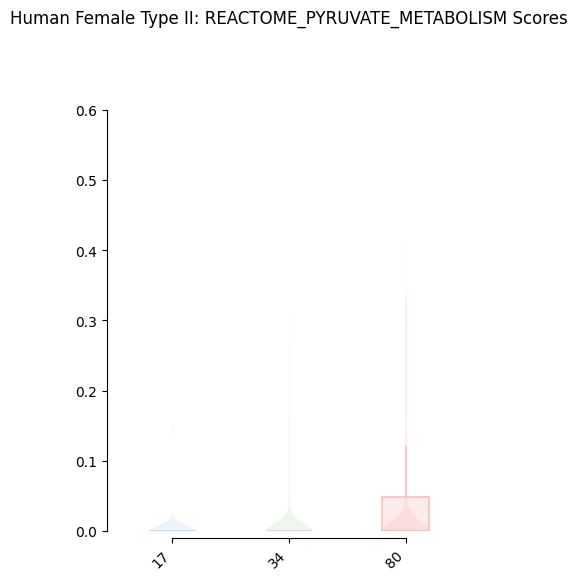

<Figure size 640x480 with 0 Axes>

In [17]:
# choose order
sample_order = ["17", "34", "80"]

# soft fill colors matching the plot
palette = {
    "17": "#C1DBF2",  # light blue
    "34": "#CAE3C4",  # light green
    "80": "#FBBDBE"   # light red/pink
}

# plot violin box plot
fig_violin_box = pgl.plot_violin_box_combo(group_score_df,
                                           x_var="age",
                                           y_var=PATHWAY,
                                           title=f"Human Female Type II: {PATHWAY} Scores",
                                           palette=palette,
                                           x_ticks=sample_order,
                                           show_scatter=False)

display(fig_violin_box)

# Gene Contribution Heatmap

In [18]:
# subset ages and get gene correlation

# get pathway genes
genes = pgl.get_pathway_genes(geneset, PATHWAY)

# subset age 17
adata_17 = pgl.subset_adata_by_obs(
    adata_human_female_typeii_common_genes,
    filters={"age": 17}
)
ranked_genes_17 = pgl.compute_gene_correlation_against_score(
    adata_17,
    genes,
    score=PATHWAY
)

# subset age 34
adata_34 = pgl.subset_adata_by_obs(
    adata_human_female_typeii_common_genes,
    filters={"age": 34}
)
ranked_genes_34 = pgl.compute_gene_correlation_against_score(
    adata_34,
    genes,
    score=PATHWAY
)

# subset age 80
adata_80 = pgl.subset_adata_by_obs(
    adata_human_female_typeii_common_genes,
    filters={"age": 80}
)
ranked_genes_80 = pgl.compute_gene_correlation_against_score(
    adata_80,
    genes,
    score=PATHWAY
)

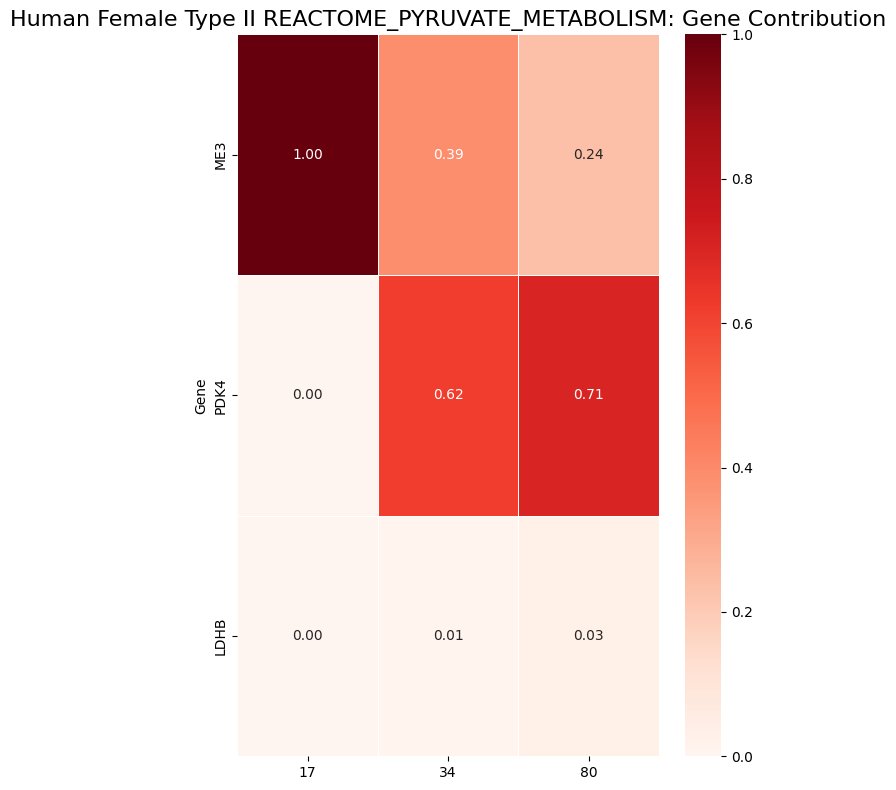

In [19]:
gene_contribution_df, fig_gene_contribution_heatmap, ax_gene_contribution = pgl.plot_gene_contribution_heatmap(
    {"17": ranked_genes_17,
     "34": ranked_genes_34,
     "80": ranked_genes_80},
     title=f"Human Female Type II {PATHWAY}: Gene Contribution"
)

# Cliffs Delta

processing: 17 vs 34
processing: 34 vs 80
processing: 17 vs 80


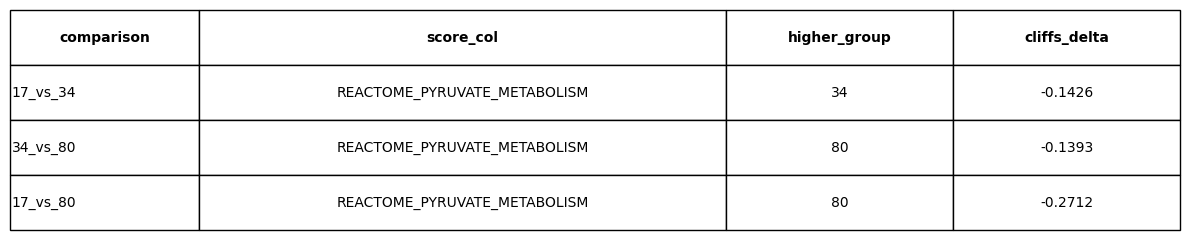

In [22]:
# calculate cliffs delta between ages

# choose age comparisons
age_comparisons = [
    (17, 34),
    (34, 80),
    (17, 80)
]

# store results
cliffs_results = []

for group1, group2 in age_comparisons:

    print(f"processing: {group1} vs {group2}")

    # calculate cliffs delta
    result_df, group_score_df = pgl.calculate_score_cliffs_delta(
        adata=adata_human_female_typeii_common_genes,
        score_col=PATHWAY,
        group_col="age",
        group1=group1,
        group2=group2
    )

    # add comparison label
    result_df.insert(0, "comparison", f"{group1}_vs_{group2}")

    # save result
    cliffs_results.append(result_df)

# combine all comparisons into one table
cliffs_df = pd.concat(cliffs_results, ignore_index=True)

# select columns for final table
cliffs_summary_df = cliffs_df[
    [
        "comparison",
        "score_col",
        "higher_group",
        "cliffs_delta"
    ]
].copy()

fig_cliffs_delta = pgl.save_df_table_image(cliffs_summary_df)

# Save Output

In [24]:
from pathlib import Path

# create output dir
output_dir = Path(f"Output/{PATHWAY}")
output_dir.mkdir(parents=True, exist_ok=True)

# violin box save paths
violin_box_png_path = output_dir / f"F_Human_TypeII_{PATHWAY}_Violin_Box_PNG.png"
violin_box_svg_path = output_dir / f"F_Human_TypeII_{PATHWAY}_Violin_Box_SVG.svg"

# gene contribution save paths
gene_contribution_png_path = output_dir / f"F_Human_TypeII_{PATHWAY}_Gene_Contribution_PNG.png"
gene_contribution_svg_path = output_dir / f"F_Human_TypeII_{PATHWAY}_Gene_Contribution_SVG.svg"

# cliffs table save path
cliffs_table_png_path = output_dir / f"F_Human_TypeII_{PATHWAY}_Cliffs_Delta_Table_PNG.png"
cliffs_table_svg_path = output_dir / f"F_Human_TypeII_{PATHWAY}_Cliffs_Delta_Table_SVG.svg"

# save violin box plot
pgl.save_fig_as_png(fig_violin_box, violin_box_png_path)
pgl.save_editable_svg(fig_violin_box, violin_box_svg_path)

# save gene contribution heatmap
pgl.save_fig_as_png(fig_gene_contribution_heatmap, gene_contribution_png_path)
pgl.save_editable_svg(fig_gene_contribution_heatmap, gene_contribution_svg_path)

# save cliffs delta table
pgl.save_fig_as_png(fig_cliffs_delta, cliffs_table_png_path)
pgl.save_editable_svg(fig_cliffs_delta, cliffs_table_svg_path)

PosixPath('Output/REACTOME_PYRUVATE_METABOLISM/F_Human_TypeII_REACTOME_PYRUVATE_METABOLISM_Cliffs_Delta_Table_SVG.svg')